
# Pre-Release Box Office Prediction and Risk Analysis

# About The Project

**This project aims to predict whether a Bollywood movie will be a 'hit' or a 'flop' based on its pre-release features. To achieve this, we trained and evaluated two machine learning models: **a Naive Bayes Classifier** and **a Decision Tree Classifier**, using a Kaggle dataset of 1,698 Hindi movies released between 2005 and 2017.**

**From a business perspective, the financial loss of investing in a flop is significantly more damaging than the opportunity cost of missing out on a hit. Therefore, our primary objective is to build a risk-less model that **maximizes the recall of 'flop' movies**. By prioritizing the accurate identification of potential flops, this model serves as a decision-support tool to help stakeholders—such as investors, producers, and theater owners—mitigate financial risk.**

**In the following sections, I will clearly define the specific features, data processing steps, and evaluation metrics used to develop and validate this model.**

# Data Description and Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
moviedata= pd.read_csv("D:/Local Disk/Downloads/Movie_data_dmml_project.csv")
moviedata.head()

,Movie Name,Release Period,Whether Remake,Whether Franchise,Genre,New Actor,New Director,New Music Director,Lead Star,Director,Music Director,Number of Screens,Revenue(INR),Budget(INR)
0,Golden Boys,Normal,No,No,suspense,Yes,No,No,Jeet Goswami,Ravi Varma,Baba Jagirdar,5,5000000,85000
1,Kaccha Limboo,Holiday,No,No,drama,Yes,No,Yes,Karan Bhanushali,Sagar Ballary,Amardeep Nijjer,75,15000000,825000
2,Not A Love Story,Holiday,No,No,thriller,No,No,No,Mahie Gill,Ram Gopal Verma,Sandeep Chowta,525,75000000,56700000
3,Qaidi Band,Holiday,No,No,drama,Yes,No,No,Aadar Jain,Habib Faisal,Amit Trivedi,800,210000000,4500000
4,Chaatwali,Holiday,No,No,adult,Yes,Yes,Yes,Aadil Khan,Aadil Khan,Babloo Ustad,1,1000000,1075000


In [3]:
moviedata.shape

(1698, 14)

In [4]:
moviedata.columns

Index(['Movie Name', 'Release Period', 'Whether Remake', 'Whether Franchise',
       'Genre', 'New Actor', 'New Director', 'New Music Director', 'Lead Star',
       'Director', 'Music Director', 'Number of Screens', 'Revenue(INR)',
       'Budget(INR)'],
      dtype='object')

In [5]:
moviedata.nunique()

Movie Name            1695
Release Period           2
Whether Remake           2
Whether Franchise        2
Genre                   14
New Actor                2
New Director             2
New Music Director       2
Lead Star              764
Director              1048
Music Director         630
Number of Screens      147
Revenue(INR)           184
Budget(INR)           1104
dtype: int64

In [6]:
moviedata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1698 entries, 0 to 1697
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Movie Name          1698 non-null   object
 1   Release Period      1698 non-null   object
 2   Whether Remake      1698 non-null   object
 3   Whether Franchise   1698 non-null   object
 4   Genre               1698 non-null   object
 5   New Actor           1698 non-null   object
 6   New Director        1698 non-null   object
 7   New Music Director  1698 non-null   object
 8   Lead Star           1698 non-null   object
 9   Director            1698 non-null   object
 10  Music Director      1698 non-null   object
 11  Number of Screens   1698 non-null   int64 
 12  Revenue(INR)        1698 non-null   int64 
 13  Budget(INR)         1698 non-null   int64 
dtypes: int64(3), object(11)
memory usage: 185.8+ KB


In [7]:
moviedata.describe()

,Number of Screens,Revenue(INR),Budget(INR)
count,1698.000000,1.698000e+03,1.698000e+03
mean,553.831567,1.501674e+08,2.377287e+08
std,782.951839,2.434838e+08,6.134398e+08
min,1.000000,3.250000e+05,7.250000e+03
25%,30.000000,1.500000e+07,1.150000e+06
50%,200.000000,5.500000e+07,1.240000e+07
75%,800.000000,1.900000e+08,1.778325e+08
max,4600.000000,2.100000e+09,8.016120e+09


In [8]:
moviedata.columns

Index(['Movie Name', 'Release Period', 'Whether Remake', 'Whether Franchise',
       'Genre', 'New Actor', 'New Director', 'New Music Director', 'Lead Star',
       'Director', 'Music Director', 'Number of Screens', 'Revenue(INR)',
       'Budget(INR)'],
      dtype='object')

**This Movie Dataset has 1698 rows and 14 columns. 
The following are the columns with its specifications:**

Categorical Columns:

    Movie Name : Title of the movie (1695 unique values) 
    Release Period: Movie releases on Normal day or Holiday (2 unique values)
    Whether Remake: Whether a remake of a movie (2 unique values)
    Whether Franchise: wheteher a franchise (2 unique Values)
    Genre : Movie falls under which category(14 unique values)
    New Actor: Whether the actor works for the movie is new one? (2 unique values)
    New Director: Whether the director works for the movie is new one? (2 unique values)
    New Music Director: Whether the music director works for the movie is new one? (2 unique values)
    Lead Star: Name of the lead actor(764 unique values)
    Director: Name of the director of the movie(1048 unique values)
    Music Director: Name of the Music Director of the movie(630 unique values)

Numerical Columns:

    Number of Screens: Movie will be released Over how many screens.
    Revenue(INR): Total revenue of the movie.
    Budget(INR): Total Cost in producing the movie.


# Data Preprocessing

## Null Values

In [9]:
moviedata.isnull().sum()

Movie Name            0
Release Period        0
Whether Remake        0
Whether Franchise     0
Genre                 0
New Actor             0
New Director          0
New Music Director    0
Lead Star             0
Director              0
Music Director        0
Number of Screens     0
Revenue(INR)          0
Budget(INR)           0
dtype: int64

****No null values found.****

## Duplicates handling

In [10]:
moviedata[moviedata.duplicated(keep=False)]

,Movie Name,Release Period,Whether Remake,Whether Franchise,Genre,New Actor,New Director,New Music Director,Lead Star,Director,Music Director,Number of Screens,Revenue(INR),Budget(INR)
40,Game,Holiday,Yes,No,thriller,No,Yes,No,Abhishek Bachchan,Abhinay Deo,Shankar - Ehsaan - Loy,1100,340000000,128792500
359,Aatma,Normal,No,No,horror,No,No,No,Bipasha Basu,Deepak Ramsay,Anu Malik,70,25000000,9400000
683,Aatma,Normal,No,No,horror,No,No,No,Bipasha Basu,Deepak Ramsay,Anu Malik,70,25000000,9400000
1269,Game,Holiday,Yes,No,thriller,No,Yes,No,Abhishek Bachchan,Abhinay Deo,Shankar - Ehsaan - Loy,1100,340000000,128792500


In [11]:
moviedata[moviedata["Movie Name"].duplicated(keep=False)]

,Movie Name,Release Period,Whether Remake,Whether Franchise,Genre,New Actor,New Director,New Music Director,Lead Star,Director,Music Director,Number of Screens,Revenue(INR),Budget(INR)
40,Game,Holiday,Yes,No,thriller,No,Yes,No,Abhishek Bachchan,Abhinay Deo,Shankar - Ehsaan - Loy,1100,340000000,128792500
359,Aatma,Normal,No,No,horror,No,No,No,Bipasha Basu,Deepak Ramsay,Anu Malik,70,25000000,9400000
541,Sanam Teri Kasam,Normal,No,No,love_story,Yes,No,No,Harshvardhan Rane,Lawrence D'Souza,Nadeem - Shravan,10,25000000,725000
683,Aatma,Normal,No,No,horror,No,No,No,Bipasha Basu,Deepak Ramsay,Anu Malik,70,25000000,9400000
1221,Sanam Teri Kasam,Normal,No,No,love_story,No,No,No,Harshvardhan Rane,Lawrence D'Souza,Nadeem - Shravan,10,25000000,725000
1269,Game,Holiday,Yes,No,thriller,No,Yes,No,Abhishek Bachchan,Abhinay Deo,Shankar - Ehsaan - Loy,1100,340000000,128792500


In [12]:
moviedata = moviedata.drop_duplicates(subset=['Movie Name'], keep='first')

In [13]:
moviedata.shape

(1695, 14)

**In finding duplicates, I found there is a catch in the dataset.** 

**It has overall 2 duplictes according to all rows but when we checked through the movie name we found 3 duplicated rows( which have only difference in New Hero Feature).** 

**I deleted all three duplicate rows using drop_duplictaes()**

## switching revenue and budget

In [14]:

moviedata=moviedata.rename(columns={'Budget(INR)':'Revenue(INR)','Revenue(INR)':'Budget(INR)'})

## Adding a new column "Outcome" with inputs as (0)Hit and (1)Flop

In [15]:
moviedata["Outcome"]= np.where(moviedata["Revenue(INR)"]> moviedata["Budget(INR)"],0,1)

****We have created a column named as "Outcome" with inputs 1 for Hit and 0 for Flop.****

# Exploratory Data Analysis

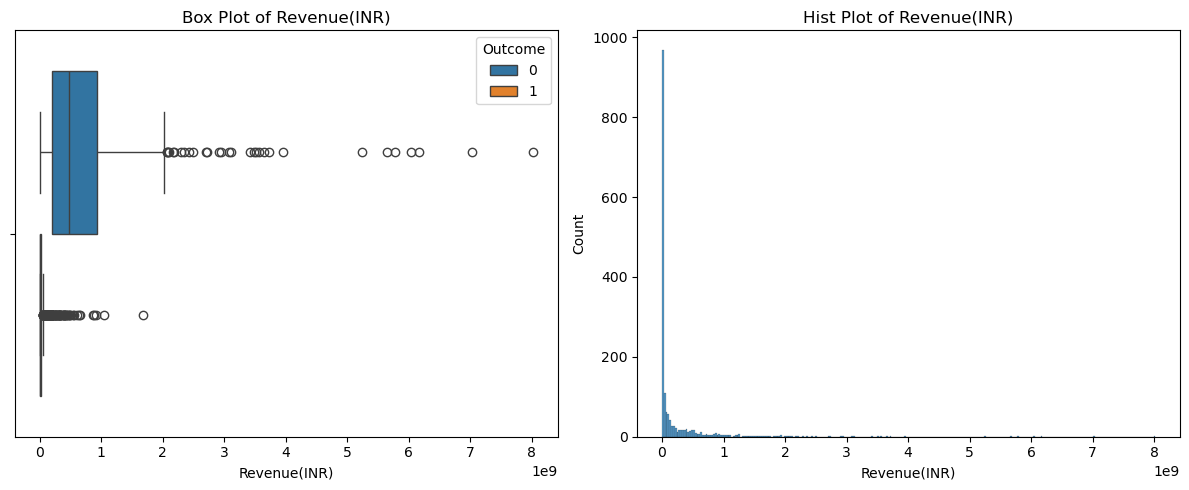

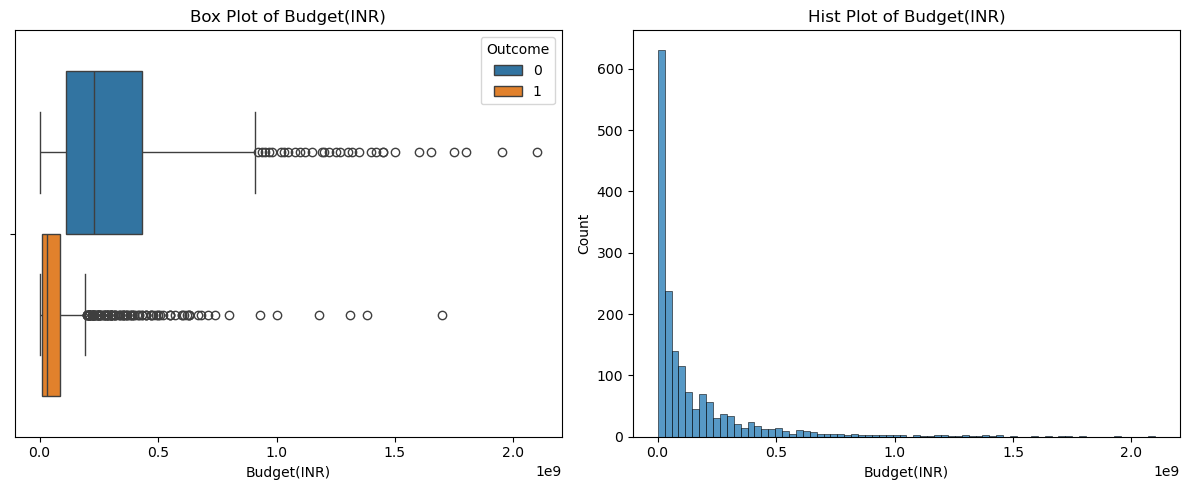

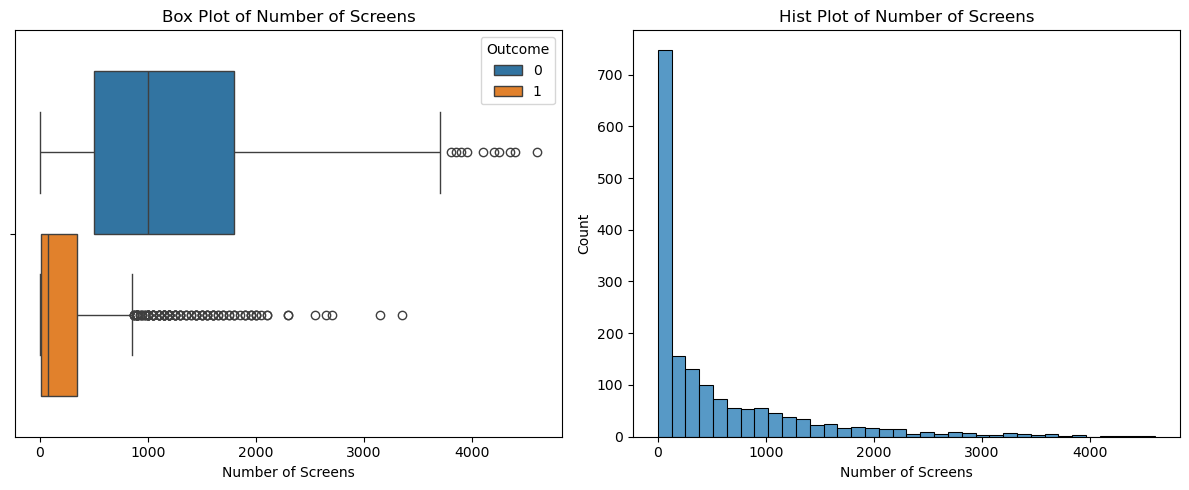

In [16]:
numcol=["Revenue(INR)","Budget(INR)","Number of Screens"]
for x in numcol:
    fig, ax = plt.subplots(nrows= 1,ncols= 2, figsize=(12,5))
    sns.boxplot(moviedata, x=x, ax= ax[0],hue="Outcome")
    ax[0].set_title(f"Box Plot of {x}")
    sns.histplot(moviedata, x=x, ax= ax[1])
    ax[1].set_title(f"Hist Plot of {x}")
    plt.tight_layout()
    plt.show()

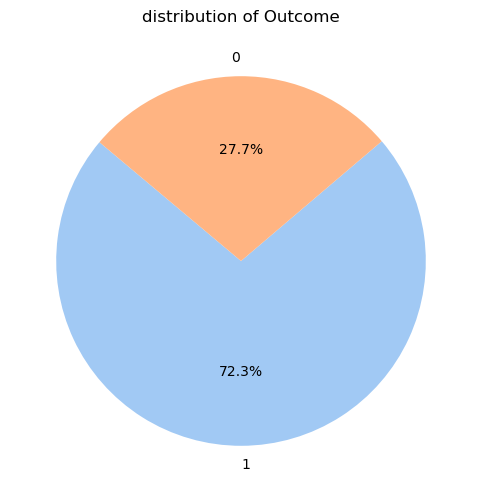

In [17]:
Outcome_counts = moviedata['Outcome'].value_counts()

plt.figure(figsize=(18,6))
plt.pie(Outcome_counts, 
        labels=Outcome_counts.index, 
        autopct='%1.1f%%', 
        startangle=140,    
        colors=sns.color_palette('pastel'))

plt.title("distribution of Outcome")
plt.show()

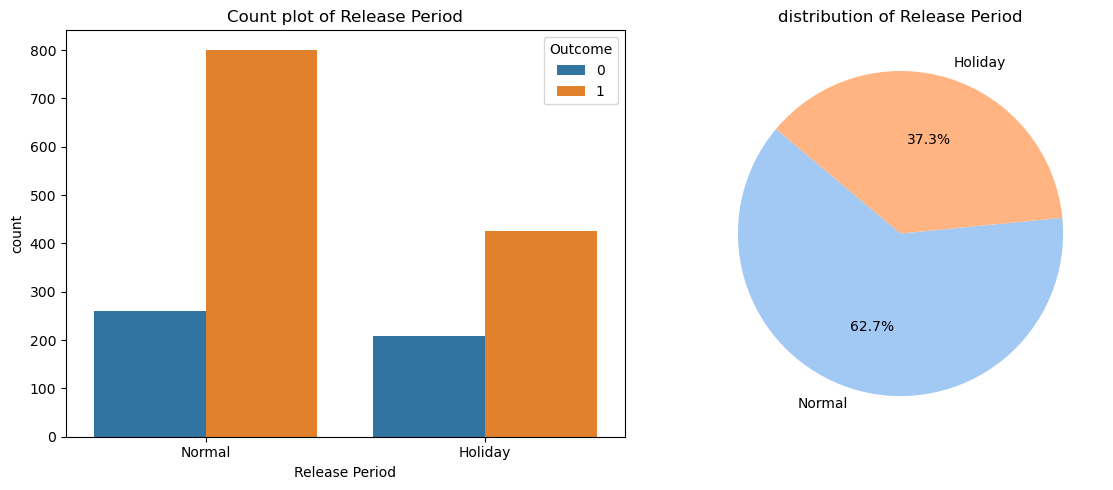

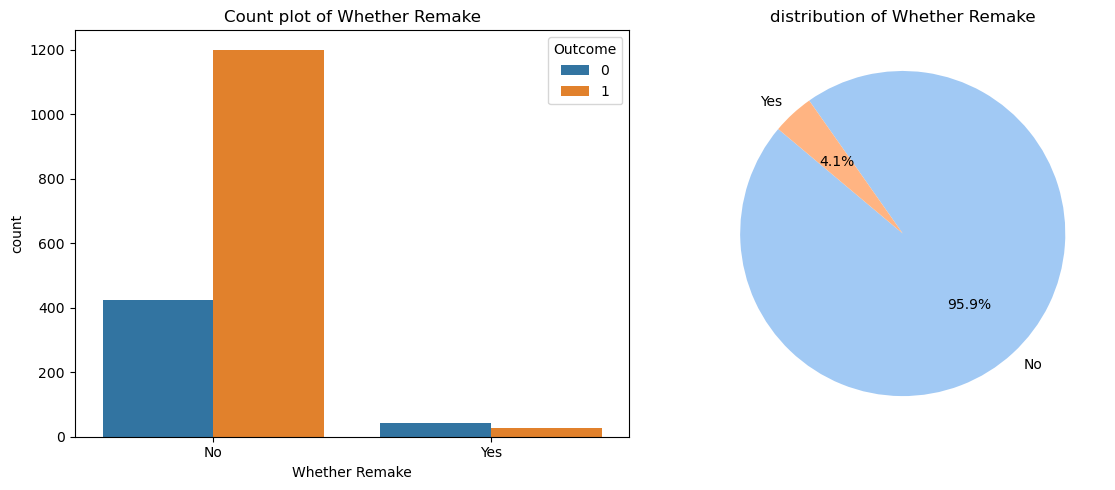

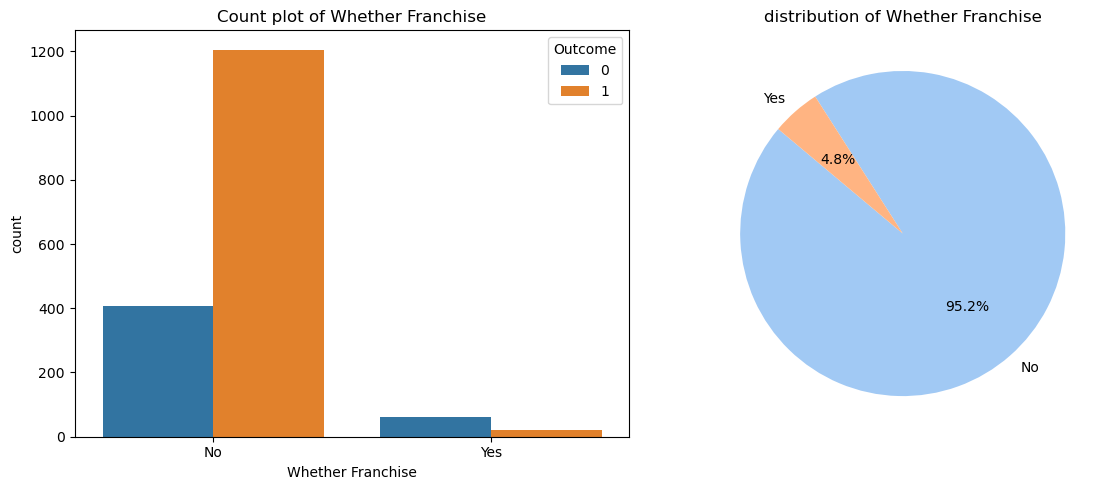

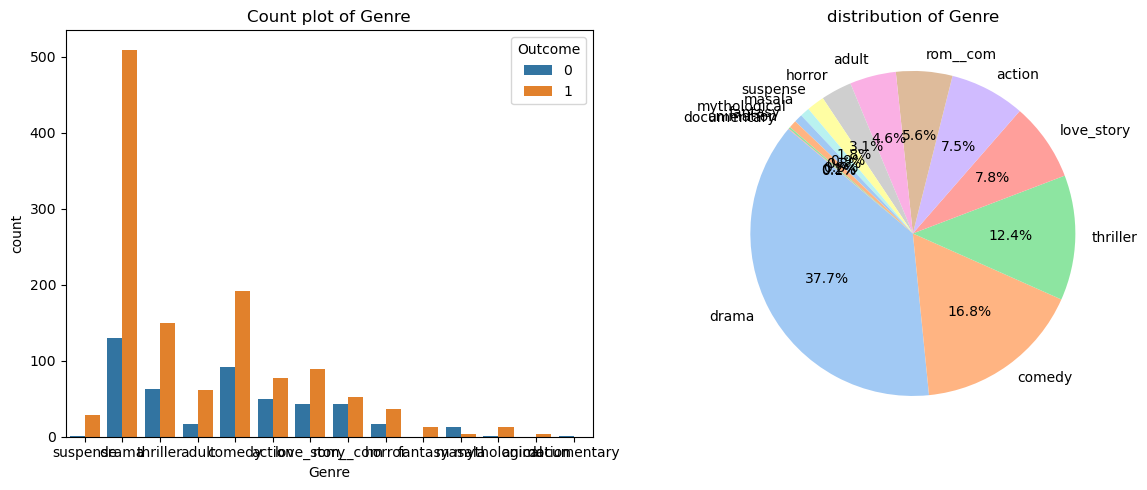

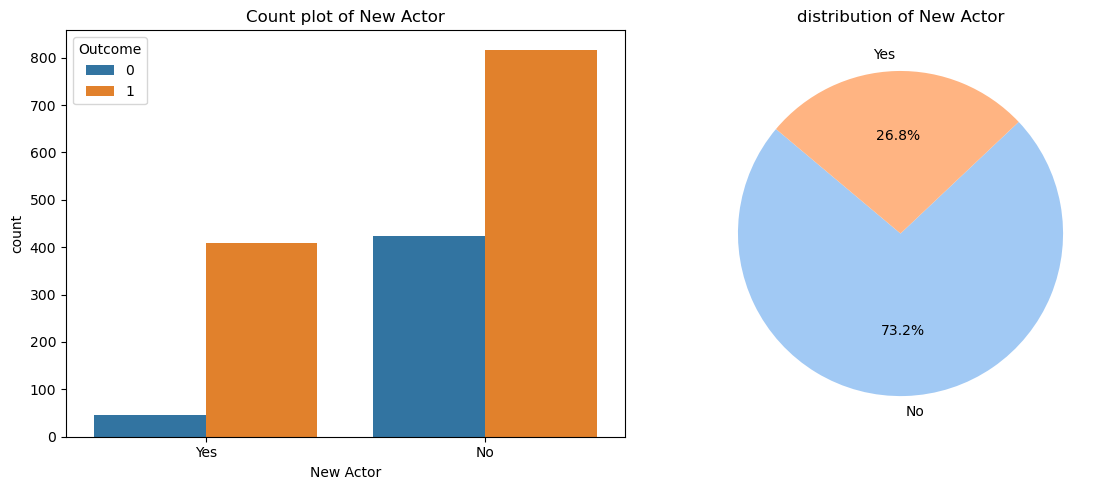

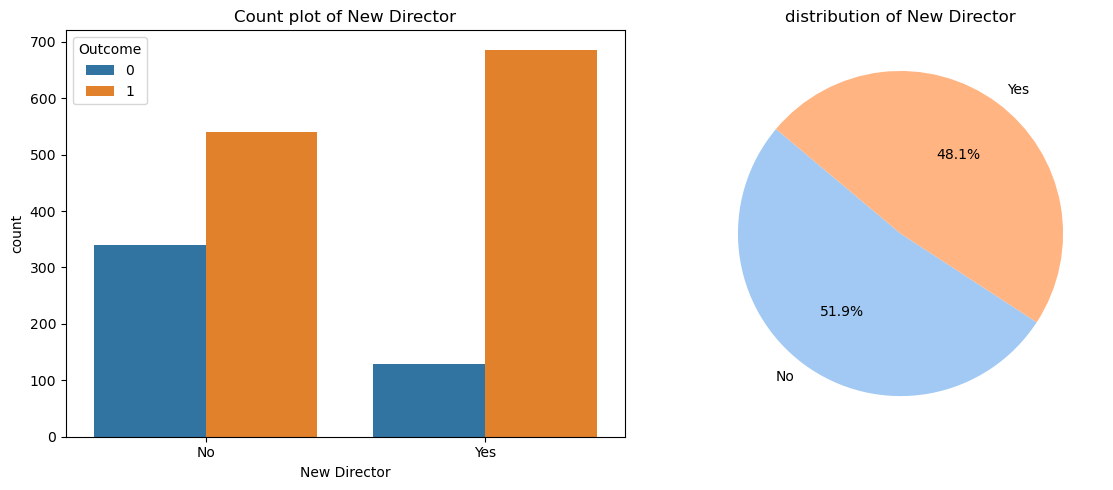

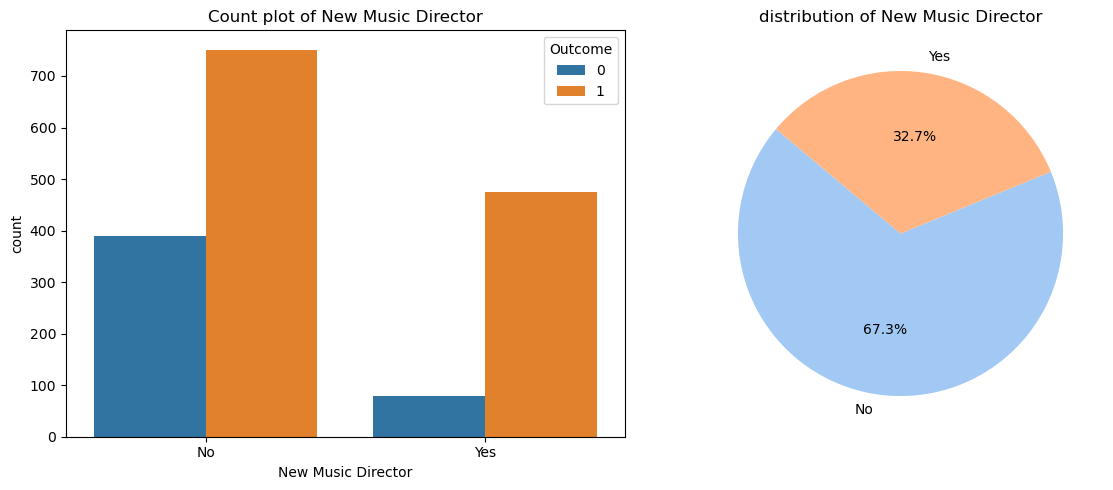

In [18]:
col_cat=['Release Period', 'Whether Remake', 'Whether Franchise',
       'Genre', 'New Actor', 'New Director', 'New Music Director']

for x in col_cat:
    fig, ax= plt.subplots(1,2,figsize=(12,5))
    sns.countplot(moviedata, x= x,hue= "Outcome", ax= ax[0])
    ax[0].set_title(f"Count plot of {x}")
    counts = moviedata[x].value_counts()
    ax[1].pie(counts, 
              labels=counts.index, 
              autopct='%1.1f%%', 
              startangle=140,    
              colors=sns.color_palette('pastel'))
    ax[1].set_title(f"distribution of {x}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

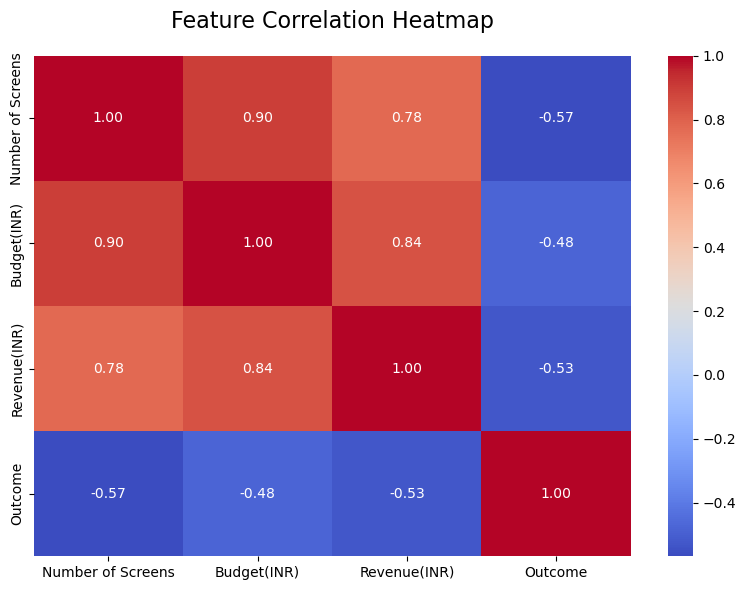

In [19]:
numerical_df =moviedata.select_dtypes(include=['float64', 'int64'])

corr_matrix = numerical_df.corr()
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

**Due to high multicollinearity between "Budget(INR)","Revenue(INR)" and "No of screens" . we have to remove two columns out of these three**

**We are going to take No of screens and remove Budget(INR)" and "Revenue(INR)"**

# Feature Engineering

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [21]:
CT= ColumnTransformer(transformers=[("std",StandardScaler(),['Number of Screens'])
       ,("ohe1",OneHotEncoder(drop='if_binary',handle_unknown="ignore"),['Release Period', 'Whether Remake', 'Whether Franchise',
       'Genre', 'New Actor', 'New Director', 'New Music Director']),
       ("ohe2",OneHotEncoder(max_categories=15,handle_unknown="ignore"),['Lead Star','Director', 'Music Director'])])

This section of code is responsible for preparing your raw Bollywood movie dataset for machine learning. It handles formatting the data, splitting it for evaluation, and packaging everything into clean, automated pipelines. 

Here is a step-by-step breakdown of every component you used and its specific purpose.

### 1. The `ColumnTransformer` (CT)
Machine learning models only understand numbers, but your dataset contains text (like Genres and Actor names) and vastly different numerical scales. The `ColumnTransformer` allows you to apply different preprocessing rules to different columns simultaneously.

* **`StandardScaler()` for 'Number of Screens':**
  * **What it does:** It standardizes the numerical column so it has a mean of 0 and a standard deviation of 1.
  * **Purpose:** If 'Number of Screens' is in the thousands, but other features are 0s and 1s, the model might mathematically assume 'Screens' is the most important feature just because the numbers are bigger. Scaling prevents this bias.

* **`OneHotEncoder(drop='if_binary')` for standard categorical columns:**
  * **What it does:** Converts text categories (like 'Genre' or 'Whether Remake') into binary (0 or 1) columns. 
  * **Purpose:** Allows the models to process text data mathematically.
  * **Special Parameter:** `drop='if_binary'` is a smart inclusion. For a column like 'Whether Remake' (Yes/No), it only creates one column instead of two. If 'Remake_Yes' is 0, the model already knows 'Remake_No' is 1. This prevents redundant data (multicollinearity). 
  * **Special Parameter:** `handle_unknown="ignore"` ensures that if the test data contains a category the model didn't see during training (e.g., a new genre), it won't crash; it will just put zeros for that feature.

* **`OneHotEncoder(max_categories=15)` for High-Cardinality columns:**
  * **What it does:** Encodes columns with hundreds of unique text values ('Lead Star', 'Director', 'Music Director'). 
  * **Purpose:** If you encoded every single Bollywood actor, you would create thousands of new columns, causing the model to overfit (the "curse of dimensionality"). `max_categories=15` keeps the top 14 most frequent actors/directors and lumps the rest into a single "Infrequent" category, keeping your dataset fast and manageable.




# Model Selection

## Importing Libraries

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

## Train Test split

In [23]:
inputcol=['Release Period', 'Whether Remake', 'Whether Franchise',
       'Genre', 'New Actor', 'New Director', 'New Music Director', 'Lead Star',
       'Director', 'Music Director', 'Number of Screens']

X= moviedata[inputcol]
Y= moviedata["Outcome"]

X_train, X_test , Y_train , Y_test= train_test_split(X,Y,random_state=123, test_size= 0.2,stratify=Y)

In [24]:
pipe_nb=Pipeline(steps=[("CT",CT),("nbclassifier",BernoulliNB(fit_prior=False))])
pipe_dtc=Pipeline(steps=[("CT",CT),("dtc",DecisionTreeClassifier(class_weight="balanced"))])


### 2. Train-Test Split

* **`train_test_split(..., test_size=0.2, stratify=Y)`**
  * **What it does:** Splits your data so 80% is used to teach the model (`X_train`, `Y_train`) and 20% is hidden away to test it later (`X_test`, `Y_test`).
  * **Purpose:** To evaluate if the model actually learned the patterns or just memorized the answers.
  * **Special Parameter:** `stratify=Y` is absolutely crucial for your project. Because you have imbalanced data (more Flops than Hits, or vice versa), this ensures that both your 80% training set and 20% testing set contain the exact same ratio of Hits to Flops as the original dataset.

### 3. The `Pipeline`

* **`Pipeline(steps=[...])`**
  * **What it does:** Chains your `ColumnTransformer` and your machine learning model together into a single object.
  * **Purpose:** It prevents "data leakage." When you call `.fit()` on the pipeline, it scales and encodes the training data, then trains the model. When you call `.predict()` on the test data, it automatically applies the exact same scaling and encoding rules before making predictions. It keeps your code exceptionally clean.

### 4. The Classifiers (The Brains)
* **`BernoulliNB(fit_prior=False)`:**
  * **What it does:** A Naive Bayes model specifically designed for binary (0 and 1) features, which matches your heavily One-Hot Encoded dataset perfectly.
  * **Purpose:** `fit_prior=False` forces the model to assume Hits and Flops are equally likely before looking at the features, rather than assuming the majority class is always the answer. This helps combat your imbalanced dataset.
* **`DecisionTreeClassifier(class_weight="balanced")`:**
  * **What it does:** A tree-based model that creates splitting rules to categorize movies.
  * **Purpose:** `class_weight="balanced"` is vital. Because you want to catch 'Flops', this parameter mathematically forces the tree to pay extra attention to the minority class, penalizing it heavily if it gets a rare outcome wrong.


## Naive Bayes Classifier (Bernoulli NB)

In [25]:
pipe_nb.fit(X_train,Y_train)

Pipeline(steps=[('CT',
                 ColumnTransformer(transformers=[('std', StandardScaler(),
                                                  ['Number of Screens']),
                                                 ('ohe1',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['Release Period',
                                                   'Whether Remake',
                                                   'Whether Franchise', 'Genre',
                                                   'New Actor', 'New Director',
                                                   'New Music Director']),
                                                 ('ohe2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                max_categories=15),
                                                  ['Lead Star', 'Director',
                                                   'Music Director'])])),
                ('nbclassifier', BernoulliNB(fit_prior=False))])

In [26]:
y_pred_nb_train= pipe_nb.predict(X_train)
y_pred_nb_test= pipe_nb.predict(X_test)
print("Training confusion_matrix :")
print(confusion_matrix(Y_train,y_pred_nb_train))
print("Testing confusion_matrix :")
print(confusion_matrix(Y_test,y_pred_nb_test))

Training confusion_matrix :
[[293  82]
 [171 810]]
Testing confusion_matrix :
[[ 83  11]
 [ 80 165]]


In [27]:
print("Training Classification Report:")
print(classification_report(Y_train,y_pred_nb_train))
print("Testing Classification Report:")
print(classification_report(Y_test,y_pred_nb_test))

Training Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.78      0.70       375
           1       0.91      0.83      0.86       981

    accuracy                           0.81      1356
   macro avg       0.77      0.80      0.78      1356
weighted avg       0.83      0.81      0.82      1356

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.88      0.65        94
           1       0.94      0.67      0.78       245

    accuracy                           0.73       339
   macro avg       0.72      0.78      0.71       339
weighted avg       0.82      0.73      0.75       339



In [28]:
print("Training Roc Auc Score:")
print(roc_auc_score(Y_train,y_pred_nb_train))
print("Testing Roc Auc Score:")
print(roc_auc_score(Y_test,y_pred_nb_test))

Training Roc Auc Score:
0.8035107033639144
Testing Roc Auc Score:
0.7782240555796787


## Decision Tree Classifier

In [29]:
pipe_dtc.fit(X_train,Y_train)

Pipeline(steps=[('CT',
                 ColumnTransformer(transformers=[('std', StandardScaler(),
                                                  ['Number of Screens']),
                                                 ('ohe1',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['Release Period',
                                                   'Whether Remake',
                                                   'Whether Franchise', 'Genre',
                                                   'New Actor', 'New Director',
                                                   'New Music Director']),
                                                 ('ohe2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                max_categories=15),
                                                  ['Lead Star', 'Director',
                                                   'Music Director'])])),
                ('dtc', DecisionTreeClassifier(class_weight='balanced'))])

In [30]:
y_pred_dtc_train= pipe_dtc.predict(X_train)
y_pred_dtc_test= pipe_dtc.predict(X_test)
print("Training confusion_matrix :")
print(confusion_matrix(Y_train,y_pred_dtc_train))
print("Testing confusion_matrix :")
print(confusion_matrix(Y_test,y_pred_dtc_test))

Training confusion_matrix :
[[374   1]
 [ 12 969]]
Testing confusion_matrix :
[[ 65  29]
 [131 114]]


In [31]:
print("Training Classification Report:")
print(classification_report(Y_train,y_pred_dtc_train))
print("Testing Classification Report:")
print(classification_report(Y_test,y_pred_dtc_test))

Training Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       375
           1       1.00      0.99      0.99       981

    accuracy                           0.99      1356
   macro avg       0.98      0.99      0.99      1356
weighted avg       0.99      0.99      0.99      1356

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.69      0.45        94
           1       0.80      0.47      0.59       245

    accuracy                           0.53       339
   macro avg       0.56      0.58      0.52       339
weighted avg       0.67      0.53      0.55       339



In [32]:
print("Training Roc Auc Score:")
print(roc_auc_score(Y_train,y_pred_dtc_train))
print("Testing Roc Auc Score:")
print(roc_auc_score(Y_test,y_pred_dtc_test))

Training Roc Auc Score:
0.9925504587155962
Testing Roc Auc Score:
0.5783977420755536


# Conclusion over Baseline Models:

In our dataset, the outcome is defined as **1 for Flop** and **0 for Hit**. To evaluate our models, we focused on three critical metrics:
* **Recall of Flops (Class 1):** The percentage of actual flops our model successfully identified. This is our primary risk-mitigation metric.
* **Precision of Hits (Class 0):** The percentage of predicted hits that actually became hits. This represents our confidence gauge for greenlighting a project.
* **Train vs. Test F1-Score:** The balance of precision and recall, used to detect if the model is learning true industry patterns or simply memorizing historical data.

---

### 2. Model Performance Comparison

| Metric | Decision Tree Classifier | Naive Bayes Classifier |
| :--- | :---: | :---: |
| **Training F1-Score (Macro)** | 0.99 | 0.78 |
| **Testing F1-Score (Macro)** | 0.48 | 0.71 |
| **Recall of Flops (Class 1)** | 42% | 67% |
| **Precision of Hits (Class 0)**| 31% | 51% |
| **Status** | Severely Overfit | Stable & Generalizable |

---





# Hyperparametric Tuning

## Decision Tree classifier

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'dtc__criterion': ['gini', 'entropy'],
    
    'dtc__max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,20], 
    
    'dtc__min_samples_split': list(range(3, 51)),  
    'dtc__min_samples_leaf': list(range(3, 31)),    
    
    'dtc__class_weight': ['balanced',None, {0: 1, 1: 5}, {0: 1, 1: 10},{0: 1, 1: 15},{0: 1, 1: 20}] 
}

dtc = DecisionTreeClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipe_dtc,
    param_distributions=param_dist,
    n_iter=100,
    scoring='f1',           
    cv=5,                       
    random_state=42,
    n_jobs=-1                   
)
print("Starting Randomized Search... this might take a minute.")
random_search.fit(X_train, Y_train)

print("\n--- Tuning Results ---")

print(f"Best Recall Score achieved during CV: {random_search.best_score_:.4f}")

print("Best Hyperparameters found:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

best_dtc_model = random_search.best_estimator_

Starting Randomized Search... this might take a minute.

--- Tuning Results ---
Best Recall Score achieved during CV: 0.8656
Best Hyperparameters found:
 - dtc__min_samples_split: 41
 - dtc__min_samples_leaf: 29
 - dtc__max_depth: 5
 - dtc__criterion: gini
 - dtc__class_weight: None


In [34]:
y_pred_dtc_train= random_search.predict(X_train)
y_pred_dtc_test= random_search.predict(X_test)
print("Training confusion_matrix :")
print(confusion_matrix(Y_train,y_pred_dtc_train))
print("Testing confusion_matrix :")
print(confusion_matrix(Y_test,y_pred_dtc_test))

Training confusion_matrix :
[[235 140]
 [ 95 886]]
Testing confusion_matrix :
[[ 58  36]
 [ 30 215]]


In [35]:
print("Training Classification Report:")
print(classification_report(Y_train,y_pred_dtc_train,))
print("Testing Classification Report:")
print(classification_report(Y_test,y_pred_dtc_test))

Training Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.63      0.67       375
           1       0.86      0.90      0.88       981

    accuracy                           0.83      1356
   macro avg       0.79      0.76      0.77      1356
weighted avg       0.82      0.83      0.82      1356

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.62      0.64        94
           1       0.86      0.88      0.87       245

    accuracy                           0.81       339
   macro avg       0.76      0.75      0.75       339
weighted avg       0.80      0.81      0.80       339



## Naive Bayes(bernoulli nb) classifier

In [36]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import RandomizedSearchCV

param_dist_nb = {
    'nbclassifier__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],  
    'nbclassifier__fit_prior': [True, False],                             
    'nbclassifier__binarize': [0.0,0.005,0.1,0.2,0.5]             
}

bnb = pipe_nb

random_search_nb = RandomizedSearchCV(
    estimator=bnb,
    param_distributions=param_dist_nb,
    n_iter=50,                      
    scoring='roc_auc',           
    cv=5,                       
    random_state=42,
    n_jobs=-1                   
)

print("Starting Randomized Search for Bernoulli NB... please wait.")
random_search_nb.fit(X_train, Y_train) 

print("\n--- Bernoulli Naive Bayes Tuning Results ---")
print(f"Best Recall Score achieved during CV: {random_search_nb.best_score_:.4f}")
print("Best Hyperparameters found:")
for param, value in random_search_nb.best_params_.items():
    print(f" - {param}: {value}")

best_bnb_model = random_search_nb.best_estimator_

Starting Randomized Search for Bernoulli NB... please wait.

--- Bernoulli Naive Bayes Tuning Results ---
Best Recall Score achieved during CV: 0.8116
Best Hyperparameters found:
 - nbclassifier__fit_prior: True
 - nbclassifier__binarize: 0.0
 - nbclassifier__alpha: 0.5


In [37]:
y_pred_nb_train= random_search_nb.predict(X_train)
y_pred_nb_test= random_search_nb.predict(X_test)
print("Training confusion_matrix :")
print(confusion_matrix(Y_train,y_pred_nb_train))
print("Testing confusion_matrix :")
print(confusion_matrix(Y_test,y_pred_nb_test))

Training confusion_matrix :
[[252 123]
 [126 855]]
Testing confusion_matrix :
[[ 77  17]
 [ 51 194]]


In [38]:
print("Training Classification Report:")
print(classification_report(Y_train,y_pred_nb_train))
print("Testing Classification Report:")
print(classification_report(Y_test,y_pred_nb_test))

Training Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67       375
           1       0.87      0.87      0.87       981

    accuracy                           0.82      1356
   macro avg       0.77      0.77      0.77      1356
weighted avg       0.82      0.82      0.82      1356

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.82      0.69        94
           1       0.92      0.79      0.85       245

    accuracy                           0.80       339
   macro avg       0.76      0.81      0.77       339
weighted avg       0.83      0.80      0.81       339



# Final Output & Business Conclusion (Post-Hyperparameter Tuning)

### 1. The Business Objective Revisited
In the film industry, the financial penalty of investing in a flop is exponentially higher than the opportunity cost of missing out on a hit. Therefore, the primary goal of this project was to build a risk-averse predictive model. 

In our dataset, the outcome is defined as **1 for Flop** and **0 for Hit**. To evaluate our models, we focused on three critical metrics:
* **Recall of Flops (Class 1):** The percentage of actual flops our model successfully identified. This is our primary risk-mitigation metric. 
* **Precision of Hits (Class 0):** The percentage of predicted hits that actually became hits. This represents our confidence gauge for greenlighting a project.
* **Train vs. Test F1-Score:** The balance of precision and recall, used to verify that the models are generalizing to new data rather than just memorizing the training set.

---

### 2. Model Performance Comparison (Tuned Models)

| Metric | Tuned Decision Tree | Tuned Naive Bayes |
| :--- | :---: | :---: |
| **Training F1-Score (Macro)** | 0.77 | 0.77 |
| **Testing F1-Score (Macro)** | 0.75 | 0.77 |
| **Recall of Flops (Class 1)** | **89%** | 79% |
| **Precision of Hits (Class 0)**| **66%** | 60% |
| **Overfitting Status** | Eliminated | None |

---

### 3. Decision Tree Classifier: The Remarkable Turnaround
Prior to hyperparameter tuning, the Decision Tree suffered from severe overfitting, memorizing the training data but failing on the test data (missing 58% of flops). 

**After tuning (restricting depth, adjusting splits, and balancing class weights), the model transformed completely:**
* **Generalization Achieved:** The training F1 (0.77) and testing F1 (0.75) are now nearly identical, proving the model has learned true, generalizable patterns about the Bollywood industry rather than just memorizing historical noise.
* **Exceptional Risk Mitigation:** The model's ability to catch financial disasters skyrocketed. It now boasts an **88% Recall for Flops** on unseen data, meaning it successfully flags nearly 9 out of 10 bad investments.
* **Improved Confidence:** When the tuned model predicts a movie will be a hit, it is correct **66%** of the time, providing a solid foundation for investment decisions.

---

### 4. Naive Bayes Classifier: Stable but Outperformed
The Naive Bayes model continued to show strong, stable performance post-tuning. Its Train and Test F1-scores are perfectly aligned (0.77), confirming it is highly robust. 

However, in the context of our specific business goals, it falls slightly short of the tuned Decision Tree. It catches fewer flops (79% Recall vs. the Tree's 88%) and has slightly lower precision when predicting hits (60% vs. the Tree's 66%).

---

### Final Recommendation
Thanks to rigorous hyperparameter tuning, the **Decision Tree Classifier is now the definitive choice for this project**.  By successfully balancing the bias-variance tradeoff, the tree transitioned from a heavily overfit algorithm into a highly effective risk-management tool. It fulfills the primary objective of the project by correctly identifying 88% of potential box office flops, making it the most reliable model for protecting stakeholder investments.

# Space And Time Profiling

## Decision Tree Classifier

In [39]:
import time
import tracemalloc

print("--- Training Decision Tree with Resource Tracking ---")

start_time = time.time()
tracemalloc.start()

pipe_dtc.fit(X_train, Y_train)


current_memory, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()
end_time = time.time()

print(f"Training Time: {end_time - start_time:.4f} seconds")
print(f"Peak Memory Usage: {peak_memory / 10**6:.4f} MB")

--- Training Decision Tree with Resource Tracking ---


Training Time: 0.1507 seconds
Peak Memory Usage: 0.6538 MB


## Bernoulli Naive Bayes Classifier

In [40]:
import time
import tracemalloc

print("--- Training Bernoulli Naive Bayes with Resource Tracking ---")

start_time = time.time()
tracemalloc.start()

pipe_nb.fit(X_train, Y_train)


current_memory, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()
end_time = time.time()

print(f"Training Time: {end_time - start_time:.4f} seconds")
print(f"Peak Memory Usage: {peak_memory / 10**6:.4f} MB")

--- Training Bernoulli Naive Bayes with Resource Tracking ---
Training Time: 0.1104 seconds
Peak Memory Usage: 0.6541 MB
